# Notebook TFM




## 1. Imports

In [1]:
import numpy as np
from scipy.linalg import expm
import cvxpy as cp
import matplotlib.pyplot as plt

## 2. Parámetros

In [2]:
#constantes
g0 = 9.807
Isp = 225
phi = np.radians(27)                 
alpha = 1/(Isp*g0*np.cos(phi))
T_max = 3.1e3
rho_min = 6*0.3*T_max*np.cos(phi)
rho_max = 6*0.8*T_max*np.cos(phi)
m_dry = 1505
m_wet = 1905
g_vec = np.array([0,0,-3.7114])
lat = np.radians(30)
T_sideral = 24.6229*3600
omega_mars = (2*np.pi/T_sideral) * np.array([np.cos(lat),0,np.sin(lat)])

gamma_p = np.radians(40)           
gamma_gs = np.radians(86)            
v_max =500/3.6

r0 = np.array([2000,0,1500])
v0 = np.array([80,30,-75])
dt = 1



## 3. Sistema continuo

In [3]:
def skew(w):
    return np.array([[0,-w[2],w[1]],[w[2],0,-w[0]],[-w[1],w[0],0]])

def build_continuous_A_B_p():
    Omega = skew(omega_mars)
    A = np.zeros((7,7))
    A[0:3,3:6] = np.eye(3)
    A[3:6,0:3] = -Omega @ Omega # centripeta
    A[3:6,3:6] = -2*Omega # Coriolis

    B = np.zeros((7, 4))
    B[3:6,0:3] = np.eye(3)
    B[6,3] = -alpha

    p = np.zeros(7)
    p[3:6] = g_vec
    return A, B, p

## 4. Discretización ZOH

In [4]:
def disc_zoh(A, B, p, dt):
    n, m = 7, 4
    Phi = np.zeros((n+m+1, n+m+1))
    Phi[:n,:n] = A*dt
    Phi[:n,n:n+m] = B*dt
    Phi[:n,-1] = p*dt
    E = expm(Phi)
    A_d = E[:n,:n]
    B_d = E[:n,n:n+m]
    p_d = E[:n,-1]
    return A_d,B_d,p_d

## 5. Solver SOCP

In [ ]:
def solve_pdg(tf, r_init=r0, v_init=v0, soft_landing=False, lam=1e3): #soft landing es el parámetro de MLE, acompañado de su lambda
    N = int(round(tf/dt))
    t_grid = np.arange(N)*dt
    m_ref = np.maximum(m_dry, m_wet - alpha*rho_max*t_grid)
    z0_ref = np.log(m_ref)           #clamp para que el log siempre exista
    A_c, B_c, p_c = build_continuous_A_B_p()
    A_d, B_d, p_d = disc_zoh(A_c, B_c, p_c, dt)

    x = cp.Variable((7,N+1))
    w = cp.Variable((4,N))
    r = x[0:3,:]
    v = x[3:6,:]
    z = x[6,:]
    u = w[0:3,:]
    xi = w[3,:]

    if soft_landing:                 
        objective = cp.Minimize(dt*cp.sum(xi)+ lam*(cp.norm(r[0:2, N], 2) + cp.norm(v[:, N], 2))) #aplicamos el MLE con su función de control
    else:
        objective = cp.Minimize(dt*cp.sum(xi))

    tan_gs = np.tan(gamma_gs)
    cons = []
    cons.append(r[:,0] == r_init)   
    cons.append(v[:,0] == v_init)
    cons.append(z[0] == np.log(m_wet))
    if soft_landing:
        cons.append(r[2, N] == 0) #solo rz es 0    
    else:
        cons.append(r[:,N] == np.zeros(3))   #todo es 0
        cons.append(v[:,N] == np.zeros(3))
        cons.append(cp.abs(r[0,N]) <= tan_gs*r[2,N])
        cons.append(cp.abs(r[1,N]) <= tan_gs*r[2,N])
    cons.append(z[N] >= np.log(m_dry))

    for k in range(N):
        cons.append(x[:,k+1] == A_d @ x[:,k] + B_d @ w[:,k] + p_d) #zoh
        cons.append(cp.norm(u[:, k], 2) <= xi[k])                  
        dz_k = z[k] - z0_ref[k]
        exp_neg_z0 = np.exp(-z0_ref[k])
        #cotas de Taylor
        cons.append(rho_min*exp_neg_z0*(1 - dz_k + 0.5*cp.square(dz_k)) <= xi[k])
        cons.append(xi[k] <= rho_max*exp_neg_z0*(1 - dz_k))
        cons.append(z[k] >= z0_ref[k]) #cota de masa (Malyuta eq 103), redundante
        cons.append(z[k] <= np.log(m_wet - alpha*rho_min*t_grid[k])) #suelo y techo de la masa
        cons.append(u[2, k] >= xi[k]*np.cos(gamma_p)) #pointing
        cons.append(cp.norm(v[:,k], 2) <= v_max) #vmax
        cons.append(cp.abs(r[0,k]) <= tan_gs*r[2,k]) #glideslope
        cons.append(cp.abs(r[1,k]) <= tan_gs*r[2,k])

    prob = cp.Problem(objective, cons)
    prob.solve(solver="CLARABEL", verbose=False)
    if prob.status not in ("optimal", "optimal_inaccurate"):
        return None #aquí detectamos los fallos

    return {
        "tf": tf, "N": N, "cost": prob.value,
        "r": r.value, "v": v.value, "z": z.value,
        "m": np.exp(z.value), "u": u.value, "xi": xi.value,
        "sigma": xi.value * np.exp(z.value[:-1]),   # sigma = xi * m
        "T": u.value * np.exp(z.value[:-1]),        # T = u * m
        "t_grid_ctrl": t_grid,
        "t_grid_state": np.arange(N+1) * dt,
    }

## 6. Tiempo de vuelo óptimo

In [6]:
def golden_search(a, b, tol=0.5):
    gr = (np.sqrt(5) - 1)/2
    def cost(tf):
        s = solve_pdg(tf)
        return np.inf if s is None else s["cost"]
    c, d = b - gr*(b-a), a + gr*(b-a)
    fc, fd = cost(c), cost(d)
    while b - a > tol:
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - gr*(b-a)
            fc = cost(c)
        else:
            a, c, fc = c, d, fd
            d = a + gr*(b-a)
            fd = cost(d)
    return round(0.5*(a + b))

tf_opt = golden_search(68, 95) #por debajo de 68 no es factible y por encima siempre gastamos más combustible
print(f"tf optimo = {tf_opt} s")

tf optimo = 75 s


## 7. Solución nominal y verificación

In [7]:
sol = solve_pdg(tf_opt)

print(f"tf = {sol['tf']:.1f} s, N = {sol['N']} nodos")
print(f"combustible = {sol['m'][0] - sol['m'][-1]:.2f} kg")
print(f"posicion final = {np.round(sol['r'][:, -1], 4)} m")
print(f"velocidad final = {np.round(sol['v'][:, -1], 4)} m/s")
print(f"masa final = {sol['m'][-1]:.2f} kg (m_dry = {m_dry})")

# verificacion de restricciones
T_norm = np.linalg.norm(sol["T"], axis=0)
u_norm = np.linalg.norm(sol["u"], axis=0)
ang = np.degrees(np.arccos(sol["u"][2] / u_norm))
v_norm = np.linalg.norm(sol["v"], axis=0)
print(f"\nempuje en [{T_norm.min():.0f}, {T_norm.max():.0f}] N  (limite [{rho_min:.0f}, {rho_max:.0f}])")
print(f"pointing maximo = {ang.max():.1f} deg  (limite {np.degrees(gamma_p):.0f})")
print(f"velocidad maxima = {v_norm.max():.1f} m/s  (limite {v_max:.1f})")

tf = 75.0 s, N = 75 nodos
combustible = 373.75 kg
posicion final = [ 0.  0. -0.] m
velocidad final = [-0. -0.  0.] m/s
masa final = 1531.25 kg (m_dry = 1505)

empuje en [4972, 13258] N  (limite [4972, 13258])
pointing maximo = 40.0 deg  (limite 40)
velocidad maxima = 113.7 m/s  (limite 138.9)


## 8. Figuras

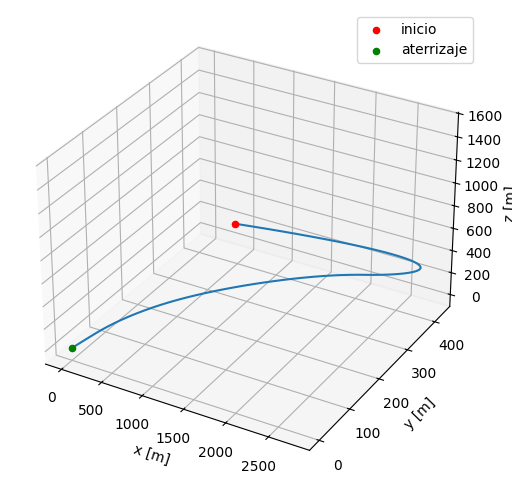

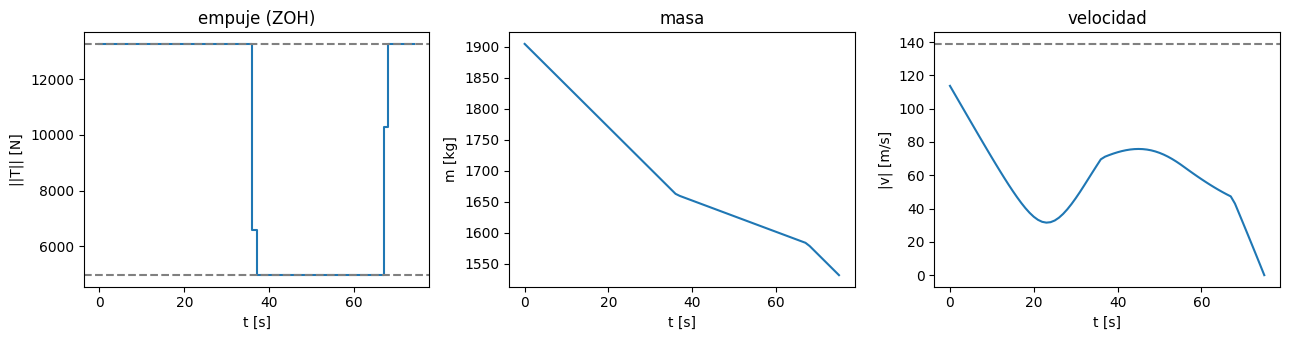

In [8]:
# trayectoria 3D
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(sol["r"][0], sol["r"][1], sol["r"][2])
ax.scatter(*sol["r"][:, 0], color="red", label="inicio")
ax.scatter(*sol["r"][:, -1], color="green", label="aterrizaje")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend(); plt.tight_layout(); plt.show()

# perfiles temporales (empuje como ZOH, estados continuos)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
ax[0].step(sol["t_grid_ctrl"], T_norm, where="post")
ax[0].axhline(rho_min, ls="--", color="gray")
ax[0].axhline(rho_max, ls="--", color="gray")
ax[0].set_title("empuje (ZOH)"); ax[0].set_xlabel("t [s]"); ax[0].set_ylabel("||T|| [N]")
ax[1].plot(sol["t_grid_state"], sol["m"])
ax[1].set_title("masa"); ax[1].set_xlabel("t [s]"); ax[1].set_ylabel("m [kg]")
ax[2].plot(sol["t_grid_state"], v_norm)
ax[2].axhline(v_max, ls="--", color="gray")
ax[2].set_title("velocidad"); ax[2].set_xlabel("t [s]"); ax[2].set_ylabel("|v| [m/s]")
plt.tight_layout(); plt.show()

## 9. Verificación RK4

In [9]:
#integra la dinamica continua con RK4 y la compara con los nodos del solver
A_c, B_c, p_c = build_continuous_A_B_p()

def f_cont(x, w):
    return A_c @ x + B_c @ w + p_c

def rk4_step(x, w, h):
    k1 = f_cont(x, w)
    k2 = f_cont(x + 0.5*h*k1, w)
    k3 = f_cont(x + 0.5*h*k2, w)
    k4 = f_cont(x + h*k3, w)
    return x + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

W = np.vstack([sol["u"], sol["xi"]])
x = np.concatenate([r0, v0, [np.log(m_wet)]])
err = 0
for k in range(sol["N"]):
    for _ in range(10): #subpasos dentro de cada intervalo ZOH
        x = rk4_step(x, W[:, k], dt/10)
    err = max(err, np.linalg.norm(x[0:3] - sol["r"][:, k+1]))
print(f"error maximo de posicion RK4 vs solver = {err:.2e} m")

error maximo de posicion RK4 vs solver = 6.45e-10 m


## 11. Extensión — Monte Carlo (dispersión de condiciones iniciales)

In [ ]:
#perturba las condiciones iniciales y clasifica: exacto / rescate MLE / fallo
rng = np.random.default_rng(0)
sigma_r, sigma_v = 100, 10 
N_mc = 1000

resultados = []
for i in range(N_mc):
    r_i = r0 + rng.normal(0,sigma_r,3)
    v_i = v0 + rng.normal(0,sigma_v,3)
    s = solve_pdg(75,r_i,v_i) #resolvemos exacto primero
    if s is not None:
        cat = "exact"
    else:
        s = solve_pdg(75,r_i,v_i,soft_landing=True)   #si no ha aterrizado, aplicamos MLE
        cat = "mle" if s is not None else "fail"
    fuel = None if s is None else float(s["m"][0] - s["m"][-1])
    resultados.append({"r": r_i, "v": v_i, "cat": cat, "fuel": fuel})

n = {c: sum(x["cat"] == c for x in resultados) for c in ["exact", "mle", "fail"]}
print(f"exacto: {n['exact']}, rescate MLE: {n['mle']}, fallo: {n['fail']} (de {N_mc})")

## 12. Distribución de combustible y diagnóstico

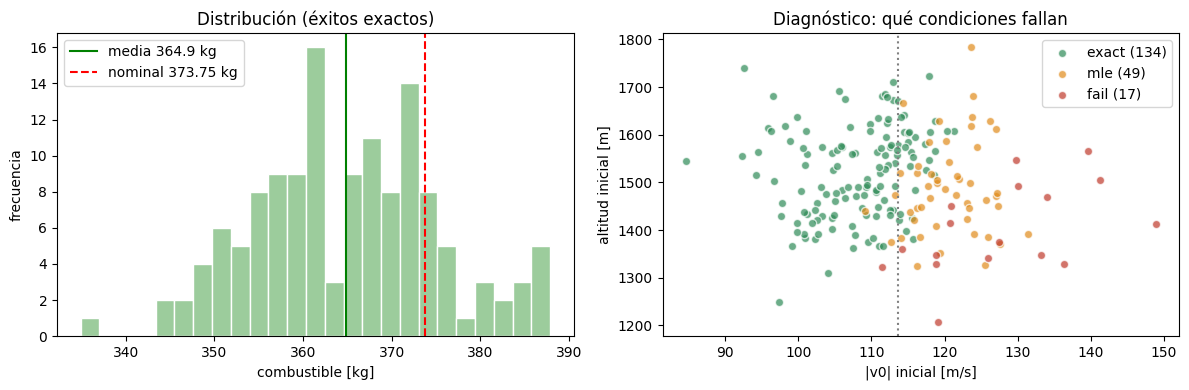

In [ ]:
fuel_ex = [x["fuel"] for x in resultados if x["cat"] == "exact"]
colores = {"exact": "#2e8b57", "mle": "#e08b1a", "fail": "#c0392b"}

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(fuel_ex, bins=25, color="#9ccc9c", edgecolor="white")
ax[0].axvline(np.mean(fuel_ex), color="green", label=f"media {np.mean(fuel_ex):.1f} kg")
ax[0].axvline(373.75, color="red", ls="--", label="nominal 373.75 kg")
ax[0].set_xlabel("combustible [kg]"); ax[0].set_ylabel("frecuencia")
ax[0].set_title("Distribución (éxitos exactos)"); ax[0].legend()

for cat in ["exact", "mle", "fail"]:
    pts = [x for x in resultados if x["cat"] == cat]
    ax[1].scatter([np.linalg.norm(x["v"]) for x in pts],
                  [x["r"][2] for x in pts],
                  c=colores[cat], label=f"{cat} ({len(pts)})", alpha=0.7,
                  edgecolors="white", s=35)
ax[1].axvline(np.linalg.norm(v0), color="gray", ls=":")
ax[1].set_xlabel("|v0| inicial [m/s]"); ax[1].set_ylabel("altitud inicial [m]")
ax[1].set_title("Diagnóstico: qué condiciones fallan"); ax[1].legend()
plt.tight_layout(); plt.show()